In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10194
Columns: 18


In [13]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost']

In [15]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [21]:
df[["Sales", "Units", "Gross Profit", "Cost"]].describe()

,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,9.166451,4.742087
std,11.341020,2.228317,6.643740,5.061647
min,1.250000,1.000000,0.250000,0.600000
25%,7.200000,2.000000,4.900000,2.400000
50%,10.800000,3.000000,7.470000,3.600000
75%,18.000000,5.000000,12.250000,5.700000
max,260.000000,14.000000,130.000000,130.000000


In [23]:
profit_check = np.isclose(
    df["Gross Profit"],
    df["Sales"] - df["Cost"]
)

print("Incorrect profit records:", (~profit_check).sum())

Incorrect profit records: 0


In [25]:
print("Zero Sales:", (df["Sales"] == 0).sum())
print("Negative Sales:", (df["Sales"] < 0).sum())

print("Zero Units:", (df["Units"] == 0).sum())
print("Negative Units:", (df["Units"] < 0).sum())

print("Zero Cost:", (df["Cost"] == 0).sum())
print("Negative Cost:", (df["Cost"] < 0).sum())

Zero Sales: 0
Negative Sales: 0
Zero Units: 0
Negative Units: 0
Zero Cost: 0
Negative Cost: 0


In [27]:
print(
    "Cost greater than Sales:",
    (df["Cost"] > df["Sales"]).sum()
)

Cost greater than Sales: 0


In [29]:
print("Negative Gross Profit:", (df["Gross Profit"] < 0).sum())
print("Zero Gross Profit:", (df["Gross Profit"] == 0).sum())

Negative Gross Profit: 0
Zero Gross Profit: 0


In [31]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [33]:
print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date Range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date Range:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date Range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [35]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping Days"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Days, dtype: float64

In [37]:
print(
    "Orders with negative shipping days:",
    (df["Shipping Days"] < 0).sum()
)

Orders with negative shipping days: 0


In [39]:
df["Gross Margin %"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

df[["Sales", "Gross Profit", "Gross Margin %"]].head()

,Sales,Gross Profit,Gross Margin %
0,6.50,4.22,64.923077
1,7.50,4.90,65.333333
2,10.47,7.47,71.346705
3,10.80,7.50,69.444444
4,11.25,7.35,65.333333


In [41]:
df["Profit per Unit"] = (
    df["Gross Profit"] / df["Units"]
)

df[["Units", "Gross Profit", "Profit per Unit"]].head()

,Units,Gross Profit,Profit per Unit
0,2,4.22,2.11
1,2,4.90,2.45
2,3,7.47,2.49
3,3,7.50,2.50
4,3,7.35,2.45


In [43]:
df["Cost %"] = (
    df["Cost"] / df["Sales"]
) * 100

df[["Sales", "Cost", "Cost %"]].head()

,Sales,Cost,Cost %
0,6.50,2.28,35.076923
1,7.50,2.60,34.666667
2,10.47,3.00,28.653295
3,10.80,3.30,30.555556
4,11.25,3.90,34.666667


In [45]:
total_sales = df["Sales"].sum()

df["Revenue Contribution %"] = (
    df["Sales"] / total_sales
) * 100

df[["Product Name", "Sales", "Revenue Contribution %"]].head()

,Product Name,Sales,Revenue Contribution %
0,Wonka Bar - Milk Chocolate,6.50,0.004584
1,Wonka Bar - Triple Dazzle Caramel,7.50,0.005290
2,Wonka Bar - Nutty Crunch Surprise,10.47,0.007384
3,Wonka Bar -Scrumdiddlyumptious,10.80,0.007617
4,Wonka Bar - Triple Dazzle Caramel,11.25,0.007935


In [47]:
total_profit = df["Gross Profit"].sum()

df["Profit Contribution %"] = (
    df["Gross Profit"] / total_profit
) * 100

df[["Product Name", "Gross Profit", "Profit Contribution %"]].head()

,Product Name,Gross Profit,Profit Contribution %
0,Wonka Bar - Milk Chocolate,4.22,0.004516
1,Wonka Bar - Triple Dazzle Caramel,4.90,0.005244
2,Wonka Bar - Nutty Crunch Surprise,7.47,0.007994
3,Wonka Bar -Scrumdiddlyumptious,7.50,0.008026
4,Wonka Bar - Triple Dazzle Caramel,7.35,0.007866


In [49]:
df["Year"] = df["Order Date"].dt.year

df[["Order Date", "Year"]].head()

,Order Date,Year
0,2024-01-03,2024
1,2024-01-04,2024
2,2024-01-04,2024
3,2024-01-04,2024
4,2024-01-05,2024


In [51]:
df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.strftime("%B")

df[["Order Date", "Month", "Month Name"]].head()

,Order Date,Month,Month Name
0,2024-01-03,1,January
1,2024-01-04,1,January
2,2024-01-04,1,January
3,2024-01-04,1,January
4,2024-01-05,1,January


In [53]:
df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.strftime("%B")

df[["Order Date", "Month", "Month Name"]].head()

,Order Date,Month,Month Name
0,2024-01-03,1,January
1,2024-01-04,1,January
2,2024-01-04,1,January
3,2024-01-04,1,January
4,2024-01-05,1,January


In [55]:
df["Year-Month"] = (
    df["Order Date"]
    .dt.to_period("M")
    .astype(str)
)

df[["Order Date", "Year-Month"]].head()

,Order Date,Year-Month
0,2024-01-03,2024-01
1,2024-01-04,2024-01
2,2024-01-04,2024-01
3,2024-01-04,2024-01
4,2024-01-05,2024-01


In [57]:
total_revenue = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()

overall_margin = (total_profit / total_revenue) * 100

total_units = df["Units"].sum()
total_orders = df["Order ID"].nunique()
total_products = df["Product ID"].nunique()
total_customers = df["Customer ID"].nunique()

avg_profit_per_unit = df["Gross Profit"].sum() / df["Units"].sum()

In [59]:
print("Total Revenue:", round(total_revenue, 2))
print("Total Cost:", round(total_cost, 2))
print("Total Gross Profit:", round(total_profit, 2))
print("Overall Gross Margin:", round(overall_margin, 2), "%")
print("Total Units:", total_units)
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)
print("Average Profit per Unit:", round(avg_profit_per_unit, 2))

Total Revenue: 141783.63
Total Cost: 48340.83
Total Gross Profit: 93442.8
Overall Gross Margin: 65.91 %
Total Units: 38654
Total Orders: 8549
Total Products: 15
Total Customers: 5044
Average Profit per Unit: 2.42


In [61]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Cost",
        "Total Gross Profit",
        "Overall Gross Margin %",
        "Total Units",
        "Total Orders",
        "Total Products",
        "Total Customers",
        "Average Profit per Unit"
    ],
    "Value": [
        total_revenue,
        total_cost,
        total_profit,
        overall_margin,
        total_units,
        total_orders,
        total_products,
        total_customers,
        avg_profit_per_unit
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,141783.630000
1,Total Cost,48340.830000
2,Total Gross Profit,93442.800000
3,Overall Gross Margin %,65.905211
4,Total Units,38654.000000
5,Total Orders,8549.000000
6,Total Products,15.000000
7,Total Customers,5044.000000
8,Average Profit per Unit,2.417416


In [63]:
kpi_summary.to_csv(
    "KPI_Summary.csv",
    index=False
)

print("KPI Summary saved successfully.")

KPI Summary saved successfully.


In [65]:
product_profitability = df.groupby(
    ["Product ID", "Product Name", "Division"],
    as_index=False
).agg({
    "Sales": "sum",
    "Units": "sum",
    "Gross Profit": "sum",
    "Cost": "sum"
})

product_profitability.head()

,Product ID,Product Name,Division,Sales,Units,Gross Profit,Cost
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,16593.60,8296.80
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,17443.37,9424.38
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,16819.95,6755.00
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,19357.50,8517.30
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,18610.20,9874.80


In [67]:
product_profitability["Gross Margin %"] = (
    product_profitability["Gross Profit"]
    / product_profitability["Sales"]
) * 100

product_profitability["Profit per Unit"] = (
    product_profitability["Gross Profit"]
    / product_profitability["Units"]
)

product_profitability["Revenue Contribution %"] = (
    product_profitability["Sales"]
    / product_profitability["Sales"].sum()
) * 100

product_profitability["Profit Contribution %"] = (
    product_profitability["Gross Profit"]
    / product_profitability["Gross Profit"].sum()
) * 100

product_profitability

,Product ID,Product Name,Division,Sales,Units,Gross Profit,Cost,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,16593.60,8296.80,66.666667,2.40,17.555200,17.758030
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11,18.949825,18.667431
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,16819.95,6755.00,71.346705,2.49,16.627413,18.000263
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,19357.50,8517.30,69.444444,2.50,19.660098,20.715882
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,18610.20,9874.80,65.333333,2.45,20.090472,19.916141
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,47.25,31.50,60.000000,2.25,0.055542,0.050566
6,OTH-GUM-21000,Wonka Gum,Other,597.50,478,310.70,286.80,52.000000,0.65,0.421417,0.332503
7,OTH-KAZ-38000,Kazookles,Other,1205.75,371,92.75,1113.00,7.692308,0.25,0.850416,0.099259
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000,10.00,5.543658,4.205782
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,104.00,26.00,80.000000,8.00,0.091689,0.111298


In [69]:
profit_rank = product_profitability.sort_values(
    "Gross Profit",
    ascending=False
)

profit_rank[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
]

,Product Name,Division,Sales,Gross Profit,Gross Margin %,Profit per Unit
3,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.444444,2.50
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.333333,2.45
1,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.923077,2.11
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.346705,2.49
0,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.666667,2.40
8,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,10.00
6,Wonka Gum,Other,597.50,310.70,52.000000,0.65
9,Everlasting Gobstopper,Sugar,130.00,104.00,80.000000,8.00
7,Kazookles,Other,1205.75,92.75,7.692308,0.25
11,Hair Toffee,Sugar,76.50,59.50,77.777778,3.50


In [71]:
margin_rank = product_profitability.sort_values(
    "Gross Margin %",
    ascending=False
)

margin_rank[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
]

,Product Name,Division,Sales,Gross Profit,Gross Margin %,Profit per Unit
9,Everlasting Gobstopper,Sugar,130.00,104.00,80.000000,8.00
11,Hair Toffee,Sugar,76.50,59.50,77.777778,3.50
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.346705,2.49
3,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.444444,2.50
0,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.666667,2.40
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.333333,2.45
1,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.923077,2.11
12,Laffy Taffy,Sugar,53.73,33.48,62.311558,1.24
5,Fizzy Lifting Drinks,Sugar,78.75,47.25,60.000000,2.25
6,Wonka Gum,Other,597.50,310.70,52.000000,0.65


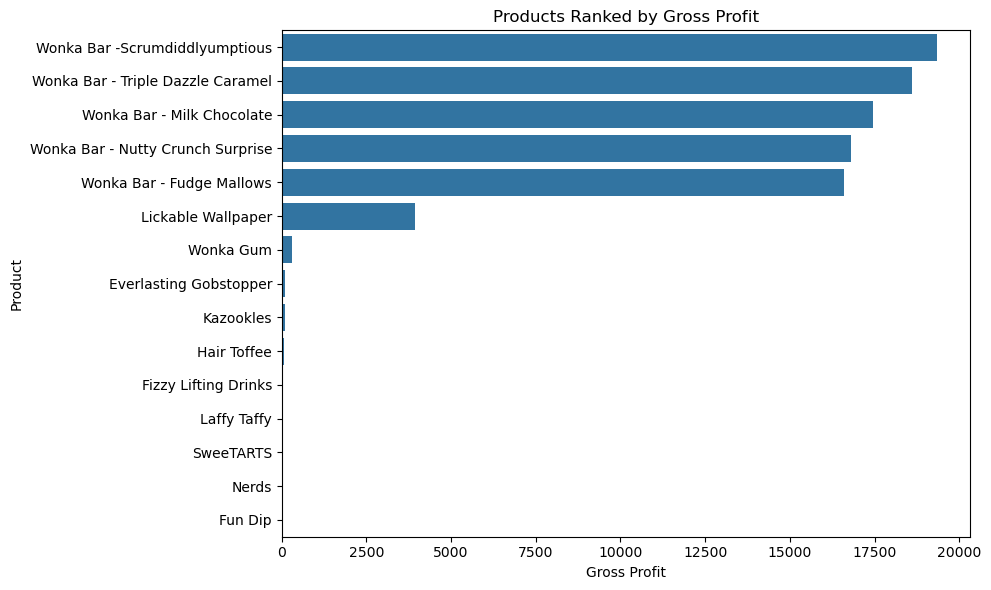

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=profit_rank,
    x="Gross Profit",
    y="Product Name"
)

plt.title("Products Ranked by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

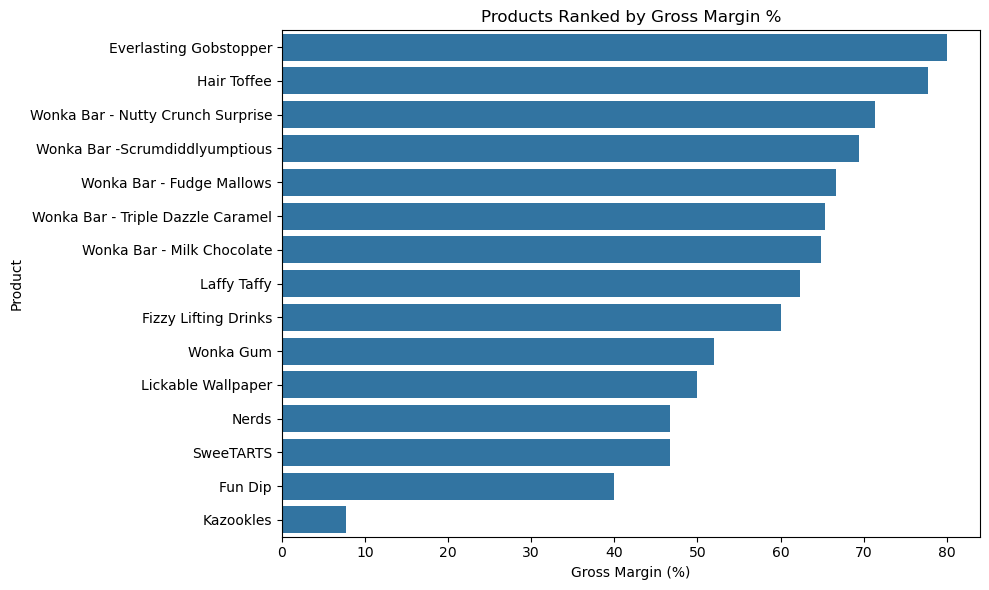

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=margin_rank,
    x="Gross Margin %",
    y="Product Name"
)

plt.title("Products Ranked by Gross Margin %")
plt.xlabel("Gross Margin (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

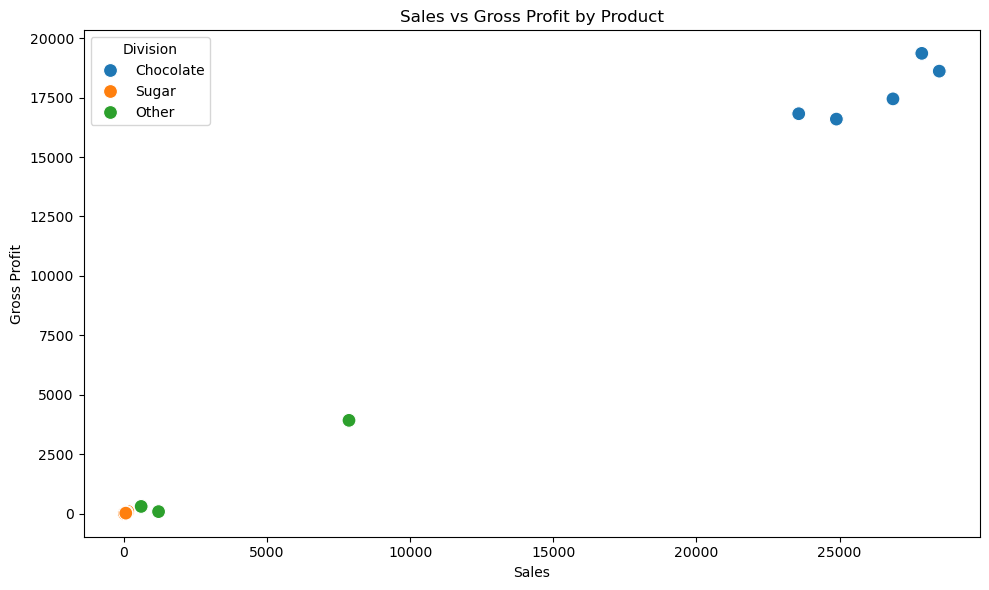

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_profitability,
    x="Sales",
    y="Gross Profit",
    hue="Division",
    s=100
)

plt.title("Sales vs Gross Profit by Product")
plt.xlabel("Sales")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.show()

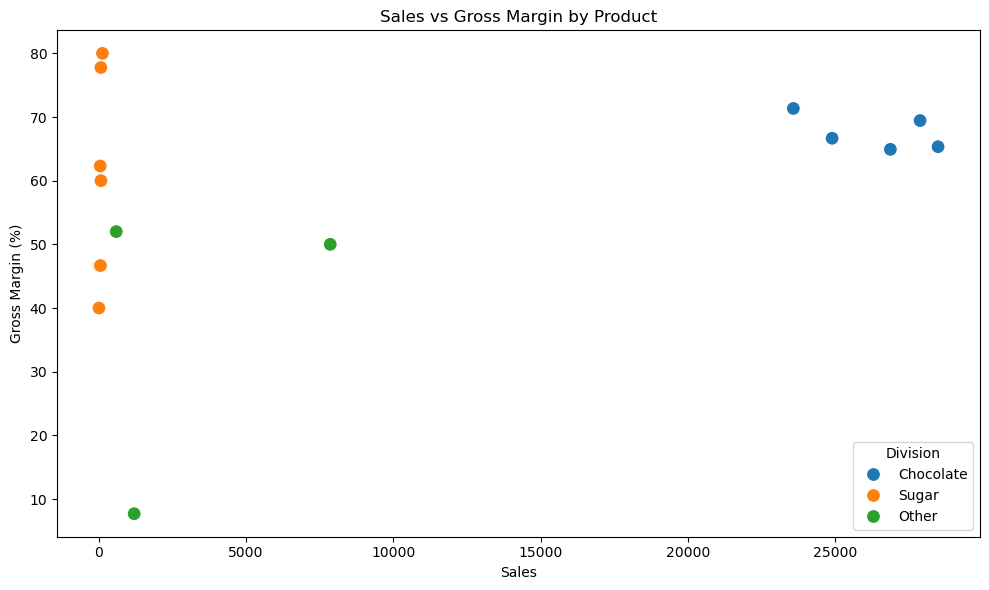

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_profitability,
    x="Sales",
    y="Gross Margin %",
    hue="Division",
    s=100
)

plt.title("Sales vs Gross Margin by Product")
plt.xlabel("Sales")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [81]:
sales_median = product_profitability["Sales"].median()
margin_median = product_profitability["Gross Margin %"].median()

print("Median Sales:", round(sales_median, 2))
print("Median Gross Margin:", round(margin_median, 2), "%")

Median Sales: 597.5
Median Gross Margin: 62.31 %


In [83]:
def classify_product(row):
    if row["Sales"] >= sales_median and row["Gross Margin %"] >= margin_median:
        return "High Sales - High Margin"
    
    elif row["Sales"] >= sales_median and row["Gross Margin %"] < margin_median:
        return "High Sales - Low Margin"
    
    elif row["Sales"] < sales_median and row["Gross Margin %"] >= margin_median:
        return "Low Sales - High Margin"
    
    else:
        return "Low Sales - Low Margin"


product_profitability["Profitability Segment"] = (
    product_profitability.apply(classify_product, axis=1)
)

product_profitability[
    ["Product Name", "Sales", "Gross Margin %", "Profitability Segment"]
]

,Product Name,Sales,Gross Margin %,Profitability Segment
0,Wonka Bar - Fudge Mallows,24890.40,66.666667,High Sales - High Margin
1,Wonka Bar - Milk Chocolate,26867.75,64.923077,High Sales - High Margin
2,Wonka Bar - Nutty Crunch Surprise,23574.95,71.346705,High Sales - High Margin
3,Wonka Bar -Scrumdiddlyumptious,27874.80,69.444444,High Sales - High Margin
4,Wonka Bar - Triple Dazzle Caramel,28485.00,65.333333,High Sales - High Margin
5,Fizzy Lifting Drinks,78.75,60.000000,Low Sales - Low Margin
6,Wonka Gum,597.50,52.000000,High Sales - Low Margin
7,Kazookles,1205.75,7.692308,High Sales - Low Margin
8,Lickable Wallpaper,7860.00,50.000000,High Sales - Low Margin
9,Everlasting Gobstopper,130.00,80.000000,Low Sales - High Margin


In [85]:
segment_counts = (
    product_profitability["Profitability Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "Profitability Segment",
    "Product Count"
]

segment_counts

,Profitability Segment,Product Count
0,High Sales - High Margin,5
1,Low Sales - Low Margin,4
2,High Sales - Low Margin,3
3,Low Sales - High Margin,3


In [87]:
high_sales_low_margin = product_profitability[
    product_profitability["Profitability Segment"]
    == "High Sales - Low Margin"
].sort_values(
    "Sales",
    ascending=False
)

high_sales_low_margin[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
]

,Product Name,Division,Sales,Gross Profit,Gross Margin %,Profit per Unit
8,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,10.00
7,Kazookles,Other,1205.75,92.75,7.692308,0.25
6,Wonka Gum,Other,597.50,310.70,52.000000,0.65


In [89]:
division_performance = df.groupby(
    "Division",
    as_index=False
).agg({
    "Sales": "sum",
    "Cost": "sum",
    "Gross Profit": "sum",
    "Units": "sum"
})

division_performance

,Division,Sales,Cost,Gross Profit,Units
0,Chocolate,131692.90,42868.28,88824.62,37275
1,Other,9663.25,5329.80,4333.45,1242
2,Sugar,427.48,142.75,284.73,137


In [91]:
division_performance["Gross Margin %"] = (
    division_performance["Gross Profit"]
    / division_performance["Sales"]
) * 100

division_performance["Profit per Unit"] = (
    division_performance["Gross Profit"]
    / division_performance["Units"]
)

division_performance["Revenue Contribution %"] = (
    division_performance["Sales"]
    / division_performance["Sales"].sum()
) * 100

division_performance["Profit Contribution %"] = (
    division_performance["Gross Profit"]
    / division_performance["Gross Profit"].sum()
) * 100

division_performance

,Division,Sales,Cost,Gross Profit,Units,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %
0,Chocolate,131692.90,42868.28,88824.62,37275,67.448298,2.382954,92.883008,95.057747
1,Other,9663.25,5329.80,4333.45,1242,44.844643,3.489090,6.815491,4.637543
2,Sugar,427.48,142.75,284.73,137,66.606625,2.078321,0.301502,0.304710


In [93]:
division_profit_rank = division_performance.sort_values(
    "Gross Profit",
    ascending=False
)

division_profit_rank[
    [
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Revenue Contribution %",
        "Profit Contribution %"
    ]
]

,Division,Sales,Gross Profit,Gross Margin %,Revenue Contribution %,Profit Contribution %
0,Chocolate,131692.90,88824.62,67.448298,92.883008,95.057747
1,Other,9663.25,4333.45,44.844643,6.815491,4.637543
2,Sugar,427.48,284.73,66.606625,0.301502,0.304710


In [95]:
division_performance["Revenue-Profit Gap"] = (
    division_performance["Revenue Contribution %"]
    - division_performance["Profit Contribution %"]
)

division_performance[
    [
        "Division",
        "Revenue Contribution %",
        "Profit Contribution %",
        "Revenue-Profit Gap"
    ]
]

,Division,Revenue Contribution %,Profit Contribution %,Revenue-Profit Gap
0,Chocolate,92.883008,95.057747,-2.174739
1,Other,6.815491,4.637543,2.177948
2,Sugar,0.301502,0.304710,-0.003209


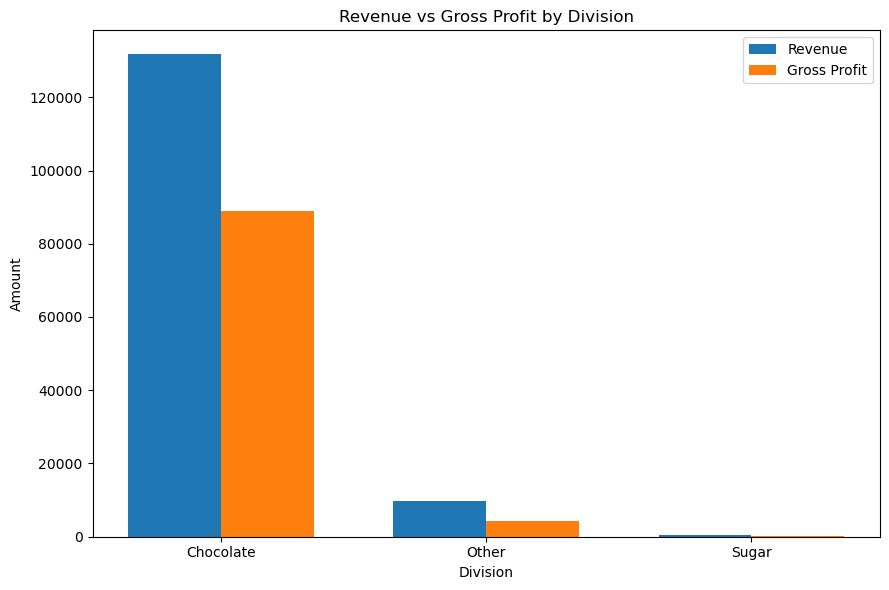

In [97]:
plt.figure(figsize=(9, 6))

x = np.arange(len(division_performance))

width = 0.35

plt.bar(
    x - width/2,
    division_performance["Sales"],
    width,
    label="Revenue"
)

plt.bar(
    x + width/2,
    division_performance["Gross Profit"],
    width,
    label="Gross Profit"
)

plt.xticks(
    x,
    division_performance["Division"]
)

plt.title("Revenue vs Gross Profit by Division")
plt.xlabel("Division")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

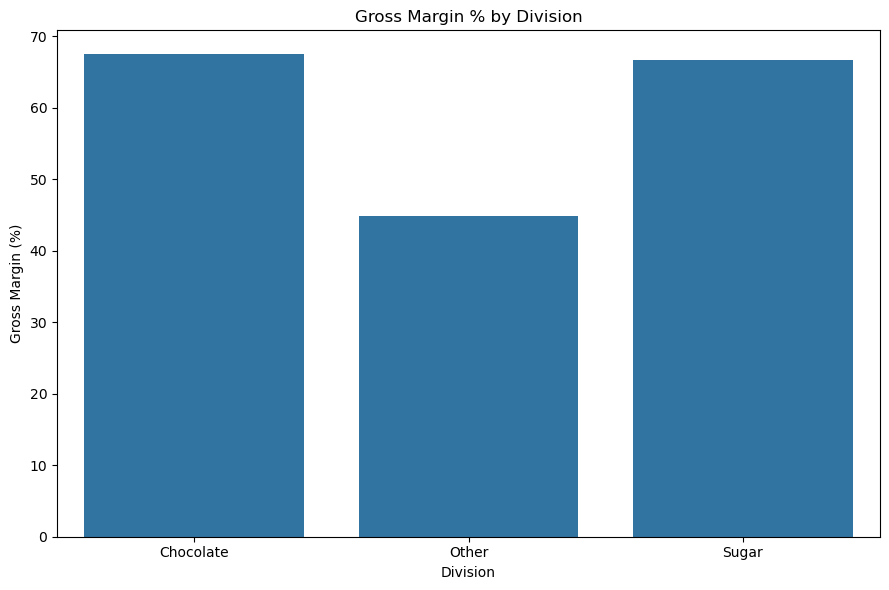

In [99]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=division_performance,
    x="Division",
    y="Gross Margin %"
)

plt.title("Gross Margin % by Division")
plt.xlabel("Division")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

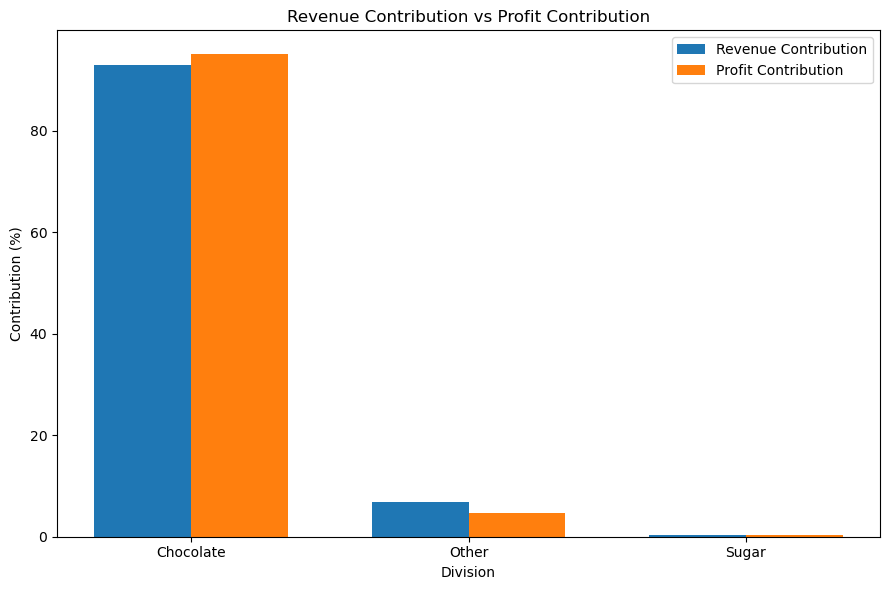

In [101]:
plt.figure(figsize=(9, 6))

x = np.arange(len(division_performance))
width = 0.35

plt.bar(
    x - width/2,
    division_performance["Revenue Contribution %"],
    width,
    label="Revenue Contribution"
)

plt.bar(
    x + width/2,
    division_performance["Profit Contribution %"],
    width,
    label="Profit Contribution"
)

plt.xticks(
    x,
    division_performance["Division"]
)

plt.title("Revenue Contribution vs Profit Contribution")
plt.xlabel("Division")
plt.ylabel("Contribution (%)")
plt.legend()
plt.tight_layout()
plt.show()

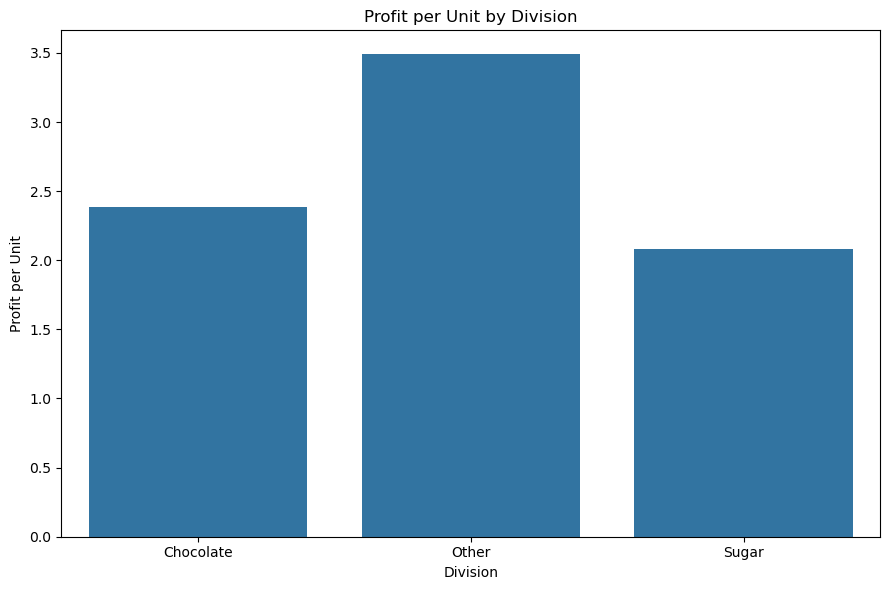

In [103]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=division_performance,
    x="Division",
    y="Profit per Unit"
)

plt.title("Profit per Unit by Division")
plt.xlabel("Division")
plt.ylabel("Profit per Unit")
plt.tight_layout()
plt.show()

In [105]:
pareto = product_profitability.sort_values(
    "Sales",
    ascending=False
).copy()

pareto["Cumulative Revenue %"] = (
    pareto["Revenue Contribution %"].cumsum()
)

pareto[
    [
        "Product Name",
        "Sales",
        "Revenue Contribution %",
        "Cumulative Revenue %"
    ]
]

,Product Name,Sales,Revenue Contribution %,Cumulative Revenue %
4,Wonka Bar - Triple Dazzle Caramel,28485.00,20.090472,20.090472
3,Wonka Bar -Scrumdiddlyumptious,27874.80,19.660098,39.750569
1,Wonka Bar - Milk Chocolate,26867.75,18.949825,58.700394
0,Wonka Bar - Fudge Mallows,24890.40,17.555200,76.255595
2,Wonka Bar - Nutty Crunch Surprise,23574.95,16.627413,92.883008
8,Lickable Wallpaper,7860.00,5.543658,98.426666
7,Kazookles,1205.75,0.850416,99.277082
6,Wonka Gum,597.50,0.421417,99.698498
9,Everlasting Gobstopper,130.00,0.091689,99.790187
5,Fizzy Lifting Drinks,78.75,0.055542,99.845730


In [107]:
pareto_profit = product_profitability.sort_values(
    "Gross Profit",
    ascending=False
).copy()

pareto_profit["Cumulative Profit %"] = (
    pareto_profit["Profit Contribution %"].cumsum()
)

pareto_profit[
    [
        "Product Name",
        "Gross Profit",
        "Profit Contribution %",
        "Cumulative Profit %"
    ]
]

,Product Name,Gross Profit,Profit Contribution %,Cumulative Profit %
3,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882,20.715882
4,Wonka Bar - Triple Dazzle Caramel,18610.20,19.916141,40.632023
1,Wonka Bar - Milk Chocolate,17443.37,18.667431,59.299454
2,Wonka Bar - Nutty Crunch Surprise,16819.95,18.000263,77.299717
0,Wonka Bar - Fudge Mallows,16593.60,17.758030,95.057747
8,Lickable Wallpaper,3930.00,4.205782,99.263528
6,Wonka Gum,310.70,0.332503,99.596031
9,Everlasting Gobstopper,104.00,0.111298,99.707329
7,Kazookles,92.75,0.099259,99.806588
11,Hair Toffee,59.50,0.063675,99.870263


In [109]:
revenue_80 = pareto[
    pareto["Cumulative Revenue %"] <= 80
].shape[0]

print(
    "Products contributing up to 80% of revenue:",
    revenue_80
)

print(
    "Percentage of products:",
    round(
        (revenue_80 / len(pareto)) * 100,
        2
    ),
    "%"
)

Products contributing up to 80% of revenue: 4
Percentage of products: 26.67 %


In [111]:
profit_80 = pareto_profit[
    pareto_profit["Cumulative Profit %"] <= 80
].shape[0]

print(
    "Products contributing up to 80% of profit:",
    profit_80
)

print(
    "Percentage of products:",
    round(
        (profit_80 / len(pareto_profit)) * 100,
        2
    ),
    "%"
)

Products contributing up to 80% of profit: 4
Percentage of products: 26.67 %


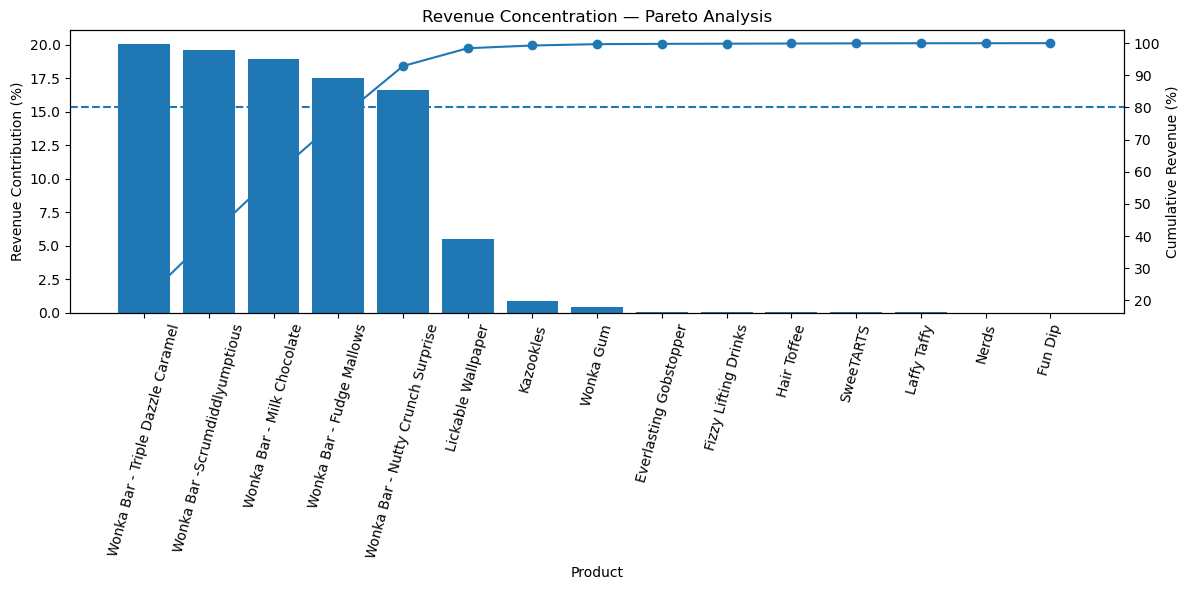

In [113]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    pareto["Product Name"],
    pareto["Revenue Contribution %"]
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Revenue Contribution (%)")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()

ax2.plot(
    pareto["Product Name"],
    pareto["Cumulative Revenue %"],
    marker="o"
)

ax2.axhline(
    80,
    linestyle="--",
    label="80% Revenue"
)

ax2.set_ylabel("Cumulative Revenue (%)")

plt.title("Revenue Concentration — Pareto Analysis")
plt.tight_layout()
plt.show()

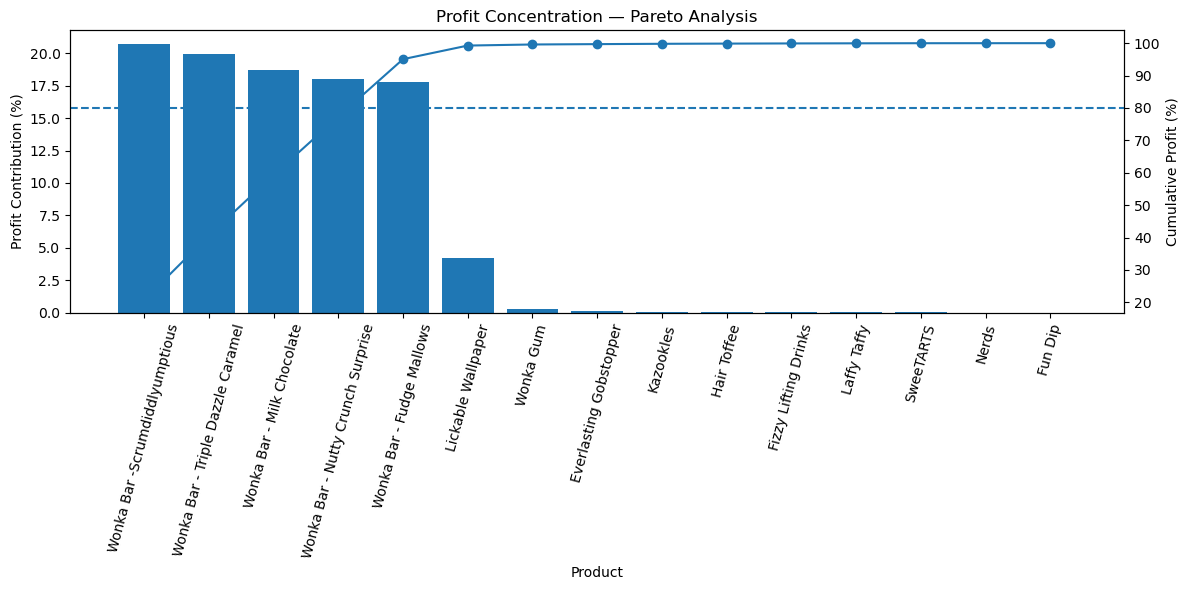

In [115]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    pareto_profit["Product Name"],
    pareto_profit["Profit Contribution %"]
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Profit Contribution (%)")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()

ax2.plot(
    pareto_profit["Product Name"],
    pareto_profit["Cumulative Profit %"],
    marker="o"
)

ax2.axhline(
    80,
    linestyle="--",
    label="80% Profit"
)

ax2.set_ylabel("Cumulative Profit (%)")

plt.title("Profit Concentration — Pareto Analysis")
plt.tight_layout()
plt.show()

In [117]:
concentration_summary = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Products for 80% Revenue",
        "% Products for 80% Revenue",
        "Products for 80% Profit",
        "% Products for 80% Profit"
    ],
    "Value": [
        len(product_profitability),
        revenue_80,
        round((revenue_80 / len(pareto)) * 100, 2),
        profit_80,
        round((profit_80 / len(pareto_profit)) * 100, 2)
    ]
})

concentration_summary

,Metric,Value
0,Total Products,15.00
1,Products for 80% Revenue,4.00
2,% Products for 80% Revenue,26.67
3,Products for 80% Profit,4.00
4,% Products for 80% Profit,26.67


In [119]:
top_profit_products = pareto_profit[
    [
        "Product Name",
        "Division",
        "Gross Profit",
        "Profit Contribution %",
        "Cumulative Profit %"
    ]
].head(10)

top_profit_products

,Product Name,Division,Gross Profit,Profit Contribution %,Cumulative Profit %
3,Wonka Bar -Scrumdiddlyumptious,Chocolate,19357.50,20.715882,20.715882
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,18610.20,19.916141,40.632023
1,Wonka Bar - Milk Chocolate,Chocolate,17443.37,18.667431,59.299454
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,16819.95,18.000263,77.299717
0,Wonka Bar - Fudge Mallows,Chocolate,16593.60,17.758030,95.057747
8,Lickable Wallpaper,Other,3930.00,4.205782,99.263528
6,Wonka Gum,Other,310.70,0.332503,99.596031
9,Everlasting Gobstopper,Sugar,104.00,0.111298,99.707329
7,Kazookles,Other,92.75,0.099259,99.806588
11,Hair Toffee,Sugar,59.50,0.063675,99.870263


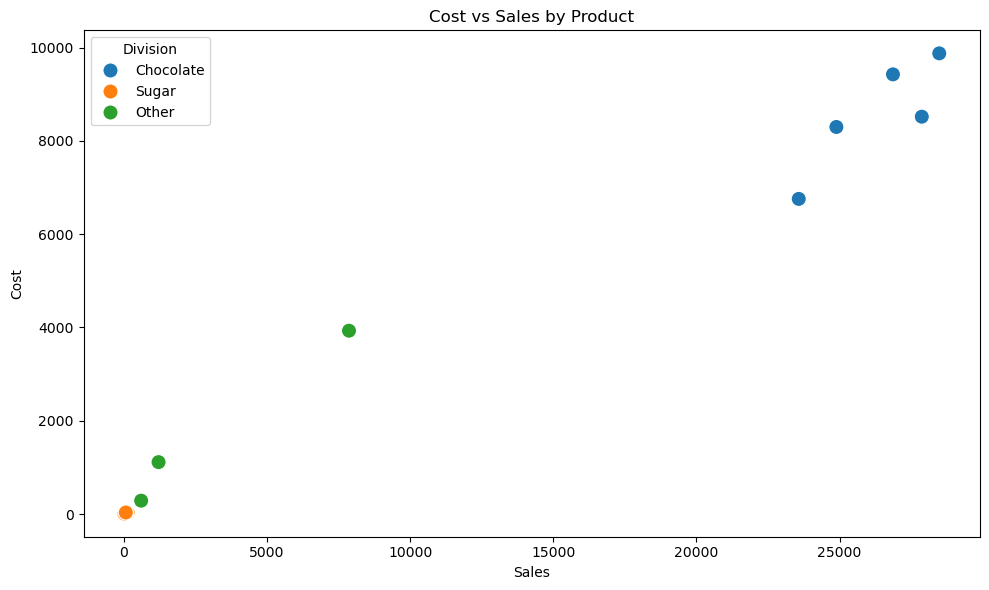

In [121]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_profitability,
    x="Sales",
    y="Cost",
    hue="Division",
    s=120
)

plt.title("Cost vs Sales by Product")
plt.xlabel("Sales")
plt.ylabel("Cost")
plt.tight_layout()
plt.show()

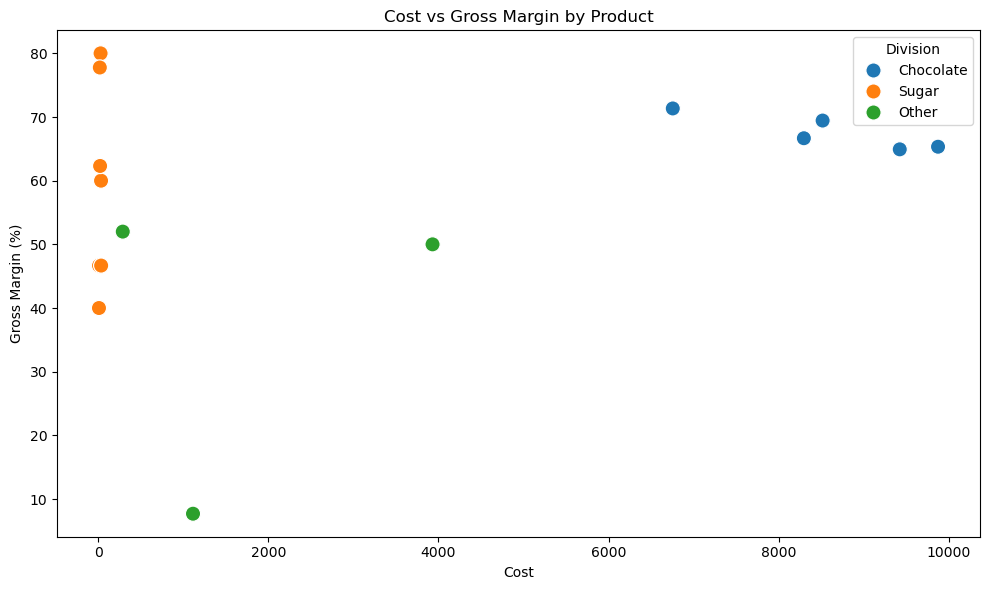

In [123]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_profitability,
    x="Cost",
    y="Gross Margin %",
    hue="Division",
    s=120
)

plt.title("Cost vs Gross Margin by Product")
plt.xlabel("Cost")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [125]:
product_profitability["Cost %"] = (
    product_profitability["Cost"]
    / product_profitability["Sales"]
) * 100

product_profitability[
    [
        "Product Name",
        "Sales",
        "Cost",
        "Cost %",
        "Gross Margin %"
    ]
].sort_values(
    "Cost %",
    ascending=False
)

,Product Name,Sales,Cost,Cost %,Gross Margin %
7,Kazookles,1205.75,1113.00,92.307692,7.692308
10,Fun Dip,12.00,7.20,60.000000,40.000000
13,Nerds,15.00,8.00,53.333333,46.666667
14,SweeTARTS,61.50,32.80,53.333333,46.666667
8,Lickable Wallpaper,7860.00,3930.00,50.000000,50.000000
6,Wonka Gum,597.50,286.80,48.000000,52.000000
5,Fizzy Lifting Drinks,78.75,31.50,40.000000,60.000000
12,Laffy Taffy,53.73,20.25,37.688442,62.311558
1,Wonka Bar - Milk Chocolate,26867.75,9424.38,35.076923,64.923077
4,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,34.666667,65.333333


In [127]:
cost_median = product_profitability["Cost %"].median()

cost_heavy_products = product_profitability[
    product_profitability["Cost %"] >= cost_median
].sort_values(
    "Cost %",
    ascending=False
)

print("Median Cost %:", round(cost_median, 2), "%")

cost_heavy_products[
    [
        "Product Name",
        "Division",
        "Sales",
        "Cost",
        "Cost %",
        "Gross Margin %",
        "Gross Profit"
    ]
]

Median Cost %: 37.69 %


,Product Name,Division,Sales,Cost,Cost %,Gross Margin %,Gross Profit
7,Kazookles,Other,1205.75,1113.00,92.307692,7.692308,92.75
10,Fun Dip,Sugar,12.00,7.20,60.000000,40.000000,4.80
13,Nerds,Sugar,15.00,8.00,53.333333,46.666667,7.00
14,SweeTARTS,Sugar,61.50,32.80,53.333333,46.666667,28.70
8,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,50.000000,3930.00
6,Wonka Gum,Other,597.50,286.80,48.000000,52.000000,310.70
5,Fizzy Lifting Drinks,Sugar,78.75,31.50,40.000000,60.000000,47.25
12,Laffy Taffy,Sugar,53.73,20.25,37.688442,62.311558,33.48


In [129]:
sales_median = product_profitability["Sales"].median()
margin_median = product_profitability["Gross Margin %"].median()
cost_median = product_profitability["Cost %"].median()

print("Sales Median:", round(sales_median, 2))
print("Margin Median:", round(margin_median, 2), "%")
print("Cost Median:", round(cost_median, 2), "%")

Sales Median: 597.5
Margin Median: 62.31 %
Cost Median: 37.69 %


In [131]:
def margin_risk(row):
    
    if (
        row["Sales"] >= sales_median
        and row["Gross Margin %"] < margin_median
        and row["Cost %"] >= cost_median
    ):
        return "High Margin Risk"
    
    elif (
        row["Gross Margin %"] < margin_median
        or row["Cost %"] >= cost_median
    ):
        return "Moderate Margin Risk"
    
    else:
        return "Low Margin Risk"


product_profitability["Margin Risk Flag"] = (
    product_profitability.apply(
        margin_risk,
        axis=1
    )
)

product_profitability[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Margin %",
        "Cost %",
        "Margin Risk Flag"
    ]
]

,Product Name,Division,Sales,Gross Margin %,Cost %,Margin Risk Flag
0,Wonka Bar - Fudge Mallows,Chocolate,24890.40,66.666667,33.333333,Low Margin Risk
1,Wonka Bar - Milk Chocolate,Chocolate,26867.75,64.923077,35.076923,Low Margin Risk
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,71.346705,28.653295,Low Margin Risk
3,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,69.444444,30.555556,Low Margin Risk
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,65.333333,34.666667,Low Margin Risk
5,Fizzy Lifting Drinks,Sugar,78.75,60.000000,40.000000,Moderate Margin Risk
6,Wonka Gum,Other,597.50,52.000000,48.000000,High Margin Risk
7,Kazookles,Other,1205.75,7.692308,92.307692,High Margin Risk
8,Lickable Wallpaper,Other,7860.00,50.000000,50.000000,High Margin Risk
9,Everlasting Gobstopper,Sugar,130.00,80.000000,20.000000,Low Margin Risk


In [133]:
risk_summary = (
    product_profitability["Margin Risk Flag"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "Margin Risk Flag",
    "Product Count"
]

risk_summary

,Margin Risk Flag,Product Count
0,Low Margin Risk,7
1,Moderate Margin Risk,5
2,High Margin Risk,3


In [135]:
risk_products = product_profitability[
    product_profitability["Margin Risk Flag"]
    == "High Margin Risk"
].sort_values(
    "Gross Margin %"
)

risk_products[
    [
        "Product Name",
        "Division",
        "Sales",
        "Cost",
        "Gross Profit",
        "Gross Margin %",
        "Cost %",
        "Profit per Unit"
    ]
]

,Product Name,Division,Sales,Cost,Gross Profit,Gross Margin %,Cost %,Profit per Unit
7,Kazookles,Other,1205.75,1113.0,92.75,7.692308,92.307692,0.25
8,Lickable Wallpaper,Other,7860.00,3930.0,3930.00,50.000000,50.000000,10.00
6,Wonka Gum,Other,597.50,286.8,310.70,52.000000,48.000000,0.65


In [137]:
monthly_product = df.groupby(
    ["Year-Month", "Product ID", "Product Name"],
    as_index=False
).agg({
    "Sales": "sum",
    "Gross Profit": "sum"
})

monthly_product["Gross Margin %"] = (
    monthly_product["Gross Profit"]
    / monthly_product["Sales"]
) * 100

monthly_product.head()

,Year-Month,Product ID,Product Name,Sales,Gross Profit,Gross Margin %
0,2024-01,CHO-FUD-51000,Wonka Bar - Fudge Mallows,338.40,225.60,66.666667
1,2024-01,CHO-MIL-31000,Wonka Bar - Milk Chocolate,565.50,367.14,64.923077
2,2024-01,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,226.85,161.85,71.346705
3,2024-01,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,248.40,172.50,69.444444
4,2024-01,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,558.75,365.05,65.333333


In [139]:
margin_volatility = monthly_product.groupby(
    ["Product ID", "Product Name"],
    as_index=False
)["Gross Margin %"].std()

margin_volatility = margin_volatility.rename(
    columns={
        "Gross Margin %": "Margin Volatility"
    }
)

margin_volatility = margin_volatility.sort_values(
    "Margin Volatility",
    ascending=False
)

margin_volatility

,Product ID,Product Name,Margin Volatility
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,1.108716e-14
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.827717e-15
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.258250e-15
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,2.963168e-15
6,OTH-GUM-21000,Wonka Gum,2.095276e-15
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,0.000000e+00
5,OTH-FIZ-56000,Fizzy Lifting Drinks,0.000000e+00
7,OTH-KAZ-38000,Kazookles,0.000000e+00
8,OTH-LIC-15000,Lickable Wallpaper,0.000000e+00
9,SUG-EVE-47000,Everlasting Gobstopper,0.000000e+00


In [141]:
product_profitability = product_profitability.merge(
    margin_volatility,
    on=["Product ID", "Product Name"],
    how="left"
)

product_profitability[
    [
        "Product Name",
        "Gross Margin %",
        "Margin Volatility"
    ]
].sort_values(
    "Margin Volatility",
    ascending=False
)

,Product Name,Gross Margin %,Margin Volatility
0,Wonka Bar - Fudge Mallows,66.666667,1.108716e-14
1,Wonka Bar - Milk Chocolate,64.923077,9.827717e-15
3,Wonka Bar -Scrumdiddlyumptious,69.444444,7.258250e-15
4,Wonka Bar - Triple Dazzle Caramel,65.333333,2.963168e-15
6,Wonka Gum,52.000000,2.095276e-15
2,Wonka Bar - Nutty Crunch Surprise,71.346705,0.000000e+00
5,Fizzy Lifting Drinks,60.000000,0.000000e+00
7,Kazookles,7.692308,0.000000e+00
8,Lickable Wallpaper,50.000000,0.000000e+00
9,Everlasting Gobstopper,80.000000,0.000000e+00


In [143]:
volatility_median = (
    product_profitability["Margin Volatility"]
    .median()
)

high_volatility_products = product_profitability[
    product_profitability["Margin Volatility"]
    >= volatility_median
].sort_values(
    "Margin Volatility",
    ascending=False
)

print(
    "Median Margin Volatility:",
    round(volatility_median, 2)
)

high_volatility_products[
    [
        "Product Name",
        "Division",
        "Gross Margin %",
        "Margin Volatility"
    ]
]

Median Margin Volatility: 0.0


,Product Name,Division,Gross Margin %,Margin Volatility
0,Wonka Bar - Fudge Mallows,Chocolate,66.666667,1.108716e-14
1,Wonka Bar - Milk Chocolate,Chocolate,64.923077,9.827717e-15
3,Wonka Bar -Scrumdiddlyumptious,Chocolate,69.444444,7.258250e-15
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,65.333333,2.963168e-15
6,Wonka Gum,Other,52.000000,2.095276e-15
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,71.346705,0.000000e+00
5,Fizzy Lifting Drinks,Sugar,60.000000,0.000000e+00
7,Kazookles,Other,7.692308,0.000000e+00
8,Lickable Wallpaper,Other,50.000000,0.000000e+00
9,Everlasting Gobstopper,Sugar,80.000000,0.000000e+00


In [145]:
regional_performance = df.groupby(
    "Region",
    as_index=False
).agg({
    "Sales": "sum",
    "Cost": "sum",
    "Gross Profit": "sum",
    "Units": "sum"
})

regional_performance

,Region,Sales,Cost,Gross Profit,Units
0,Atlantic,41197.24,14223.54,26973.70,11159
1,Gulf,22247.26,7546.59,14700.67,6209
2,Interior,32037.60,10755.11,21282.49,8820
3,Pacific,46301.53,15815.59,30485.94,12466


In [147]:
regional_performance["Gross Margin %"] = (
    regional_performance["Gross Profit"]
    / regional_performance["Sales"]
) * 100

regional_performance["Profit per Unit"] = (
    regional_performance["Gross Profit"]
    / regional_performance["Units"]
)

regional_performance["Revenue Contribution %"] = (
    regional_performance["Sales"]
    / regional_performance["Sales"].sum()
) * 100

regional_performance["Profit Contribution %"] = (
    regional_performance["Gross Profit"]
    / regional_performance["Gross Profit"].sum()
) * 100

regional_performance

,Region,Sales,Cost,Gross Profit,Units,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %
0,Atlantic,41197.24,14223.54,26973.70,11159,65.474532,2.417215,29.056415,28.866537
1,Gulf,22247.26,7546.59,14700.67,6209,66.078564,2.367639,15.690993,15.732266
2,Interior,32037.60,10755.11,21282.49,8820,66.429726,2.412981,22.596121,22.775955
3,Pacific,46301.53,15815.59,30485.94,12466,65.842187,2.445527,32.656471,32.625242


In [149]:
regional_profit_rank = regional_performance.sort_values(
    "Gross Profit",
    ascending=False
)

regional_profit_rank[
    [
        "Region",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
]

,Region,Sales,Gross Profit,Gross Margin %,Profit per Unit
3,Pacific,46301.53,30485.94,65.842187,2.445527
0,Atlantic,41197.24,26973.70,65.474532,2.417215
2,Interior,32037.60,21282.49,66.429726,2.412981
1,Gulf,22247.26,14700.67,66.078564,2.367639


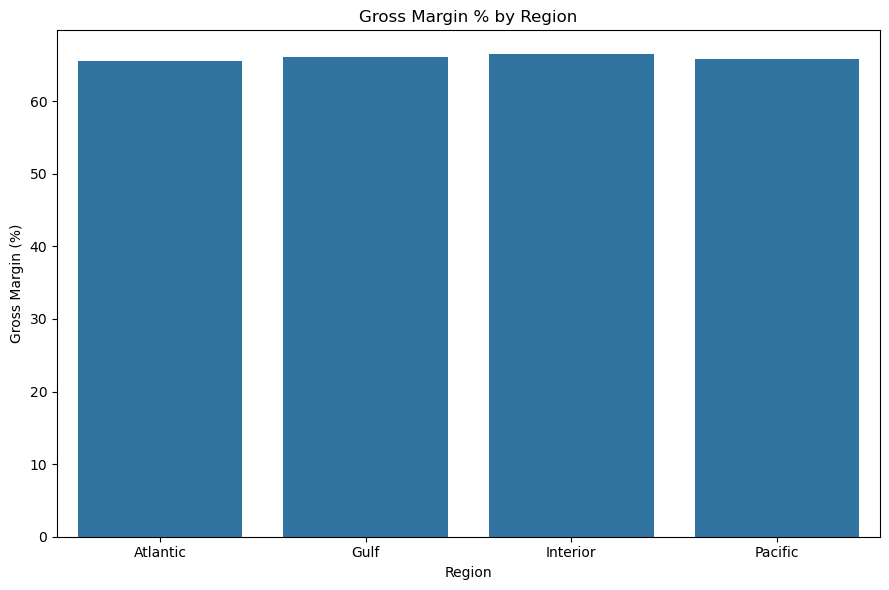

In [151]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=regional_performance,
    x="Region",
    y="Gross Margin %"
)

plt.title("Gross Margin % by Region")
plt.xlabel("Region")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [153]:
monthly_performance = df.groupby(
    "Year-Month",
    as_index=False
).agg({
    "Sales": "sum",
    "Cost": "sum",
    "Gross Profit": "sum",
    "Units": "sum"
})

monthly_performance["Gross Margin %"] = (
    monthly_performance["Gross Profit"]
    / monthly_performance["Sales"]
) * 100

monthly_performance

,Year-Month,Sales,Cost,Gross Profit,Units,Gross Margin %
0,2024-01,2093.90,727.76,1366.14,566,65.243803
1,2024-02,1379.87,471.28,908.59,398,65.846058
2,2024-03,4138.90,1467.74,2671.16,1125,64.537921
3,2024-04,3988.22,1375.41,2612.81,1079,65.513186
4,2024-05,3951.52,1336.08,2615.44,1099,66.188201
5,2024-06,3518.76,1188.04,2330.72,1010,66.236970
6,2024-07,3865.38,1300.12,2565.26,1107,66.365015
7,2024-08,4477.65,1531.78,2945.87,1227,65.790537
8,2024-09,7912.10,2705.40,5206.70,2105,65.806802
9,2024-10,4815.98,1696.52,3119.46,1237,64.773110


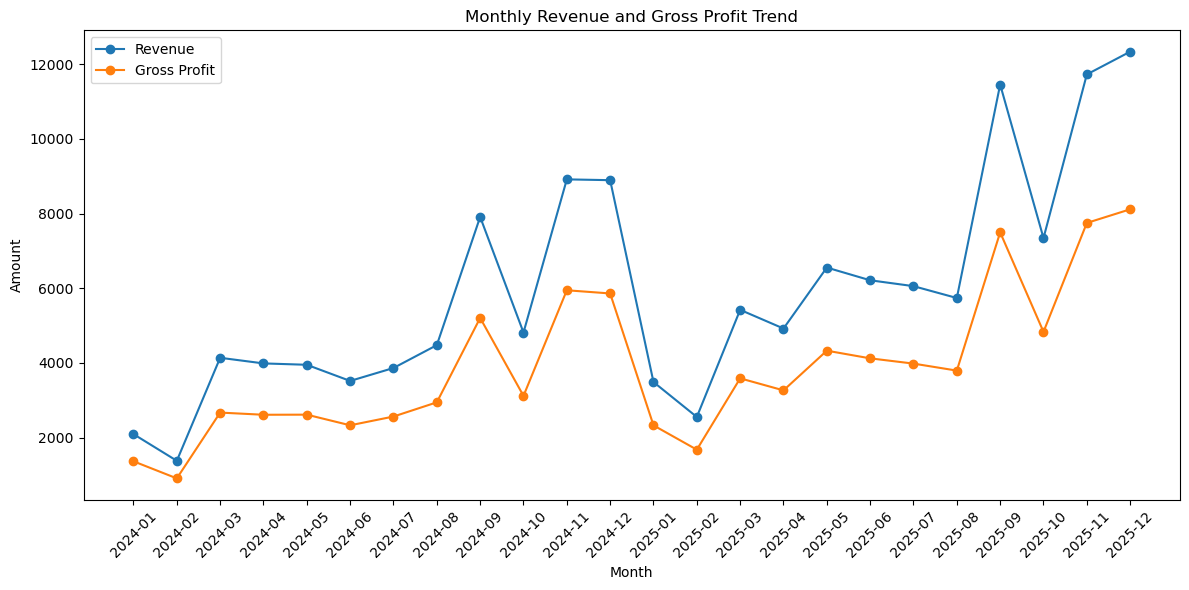

In [155]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Sales"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Gross Profit"],
    marker="o",
    label="Gross Profit"
)

plt.title("Monthly Revenue and Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

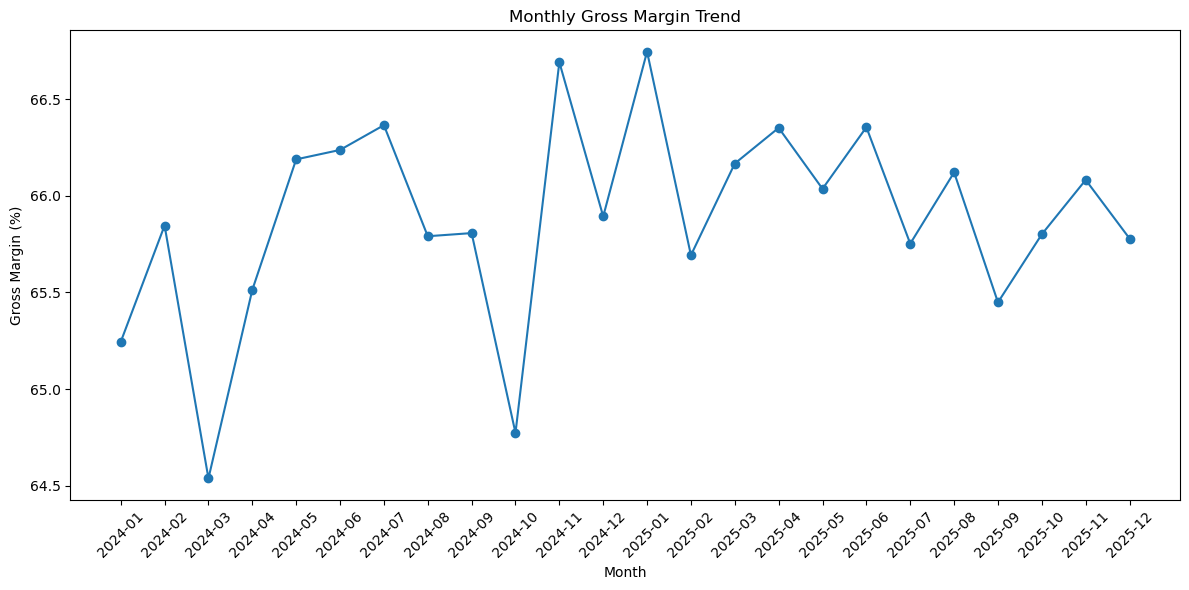

In [157]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Gross Margin %"],
    marker="o"
)

plt.title("Monthly Gross Margin Trend")
plt.xlabel("Month")
plt.ylabel("Gross Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [159]:
best_margin_month = monthly_performance.loc[
    monthly_performance["Gross Margin %"].idxmax()
]

weakest_margin_month = monthly_performance.loc[
    monthly_performance["Gross Margin %"].idxmin()
]

print("Best Margin Month:")
print(best_margin_month)

print("\nWeakest Margin Month:")
print(weakest_margin_month)

Best Margin Month:
Year-Month          2025-01
Sales                3489.1
Cost                1160.29
Gross Profit        2328.81
Units                  1003
Gross Margin %    66.745292
Name: 12, dtype: object

Weakest Margin Month:
Year-Month          2024-03
Sales                4138.9
Cost                1467.74
Gross Profit        2671.16
Units                  1125
Gross Margin %    64.537921
Name: 2, dtype: object


In [161]:
product_analysis = product_profitability[
    [
        "Product ID",
        "Product Name",
        "Division",
        "Sales",
        "Units",
        "Cost",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit",
        "Revenue Contribution %",
        "Profit Contribution %",
        "Cost %",
        "Profitability Segment",
        "Margin Risk Flag",
        "Margin Volatility"
    ]
].copy()

product_analysis

,Product ID,Product Name,Division,Sales,Units,Cost,Gross Profit,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %,Cost %,Profitability Segment,Margin Risk Flag,Margin Volatility
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,17.555200,17.758030,33.333333,High Sales - High Margin,Low Margin Risk,1.108716e-14
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,18.949825,18.667431,35.076923,High Sales - High Margin,Low Margin Risk,9.827717e-15
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,16.627413,18.000263,28.653295,High Sales - High Margin,Low Margin Risk,0.000000e+00
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,19.660098,20.715882,30.555556,High Sales - High Margin,Low Margin Risk,7.258250e-15
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,20.090472,19.916141,34.666667,High Sales - High Margin,Low Margin Risk,2.963168e-15
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.000000,2.25,0.055542,0.050566,40.000000,Low Sales - Low Margin,Moderate Margin Risk,0.000000e+00
6,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.000000,0.65,0.421417,0.332503,48.000000,High Sales - Low Margin,High Margin Risk,2.095276e-15
7,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.692308,0.25,0.850416,0.099259,92.307692,High Sales - Low Margin,High Margin Risk,0.000000e+00
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000,10.00,5.543658,4.205782,50.000000,High Sales - Low Margin,High Margin Risk,0.000000e+00
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.091689,0.111298,20.000000,Low Sales - High Margin,Low Margin Risk,0.000000e+00


In [163]:
product_analysis["Risk Score"] = (
    (product_analysis["Gross Margin %"] < margin_median).astype(int)
    +
    (product_analysis["Cost %"] >= cost_median).astype(int)
    +
    (product_analysis["Margin Volatility"] >= volatility_median).fillna(False).astype(int)
    +
    (
        (product_analysis["Sales"] >= sales_median)
        &
        (product_analysis["Gross Margin %"] < margin_median)
    ).astype(int)
)

product_analysis[
    [
        "Product Name",
        "Gross Margin %",
        "Cost %",
        "Margin Volatility",
        "Risk Score"
    ]
].sort_values(
    "Risk Score",
    ascending=False
)

,Product Name,Gross Margin %,Cost %,Margin Volatility,Risk Score
6,Wonka Gum,52.000000,48.000000,2.095276e-15,4
7,Kazookles,7.692308,92.307692,0.000000e+00,4
8,Lickable Wallpaper,50.000000,50.000000,0.000000e+00,4
5,Fizzy Lifting Drinks,60.000000,40.000000,0.000000e+00,3
10,Fun Dip,40.000000,60.000000,0.000000e+00,3
13,Nerds,46.666667,53.333333,0.000000e+00,3
14,SweeTARTS,46.666667,53.333333,0.000000e+00,3
12,Laffy Taffy,62.311558,37.688442,0.000000e+00,2
0,Wonka Bar - Fudge Mallows,66.666667,33.333333,1.108716e-14,1
1,Wonka Bar - Milk Chocolate,64.923077,35.076923,9.827717e-15,1


In [165]:
def management_category(score):
    if score >= 3:
        return "Priority Review"
    elif score == 2:
        return "Monitor"
    else:
        return "Stable"


product_analysis["Management Category"] = (
    product_analysis["Risk Score"]
    .apply(management_category)
)

product_analysis[
    [
        "Product Name",
        "Division",
        "Risk Score",
        "Management Category"
    ]
].sort_values(
    "Risk Score",
    ascending=False
)

,Product Name,Division,Risk Score,Management Category
6,Wonka Gum,Other,4,Priority Review
7,Kazookles,Other,4,Priority Review
8,Lickable Wallpaper,Other,4,Priority Review
5,Fizzy Lifting Drinks,Sugar,3,Priority Review
10,Fun Dip,Sugar,3,Priority Review
13,Nerds,Sugar,3,Priority Review
14,SweeTARTS,Sugar,3,Priority Review
12,Laffy Taffy,Sugar,2,Monitor
0,Wonka Bar - Fudge Mallows,Chocolate,1,Stable
1,Wonka Bar - Milk Chocolate,Chocolate,1,Stable


In [167]:
priority_products = product_analysis[
    product_analysis["Management Category"]
    == "Priority Review"
].sort_values(
    "Risk Score",
    ascending=False
)

priority_products[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Cost %",
        "Margin Volatility",
        "Risk Score"
    ]
]

,Product Name,Division,Sales,Gross Profit,Gross Margin %,Cost %,Margin Volatility,Risk Score
6,Wonka Gum,Other,597.50,310.70,52.000000,48.000000,2.095276e-15,4
7,Kazookles,Other,1205.75,92.75,7.692308,92.307692,0.000000e+00,4
8,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,50.000000,0.000000e+00,4
5,Fizzy Lifting Drinks,Sugar,78.75,47.25,60.000000,40.000000,0.000000e+00,3
10,Fun Dip,Sugar,12.00,4.80,40.000000,60.000000,0.000000e+00,3
13,Nerds,Sugar,15.00,7.00,46.666667,53.333333,0.000000e+00,3
14,SweeTARTS,Sugar,61.50,28.70,46.666667,53.333333,0.000000e+00,3


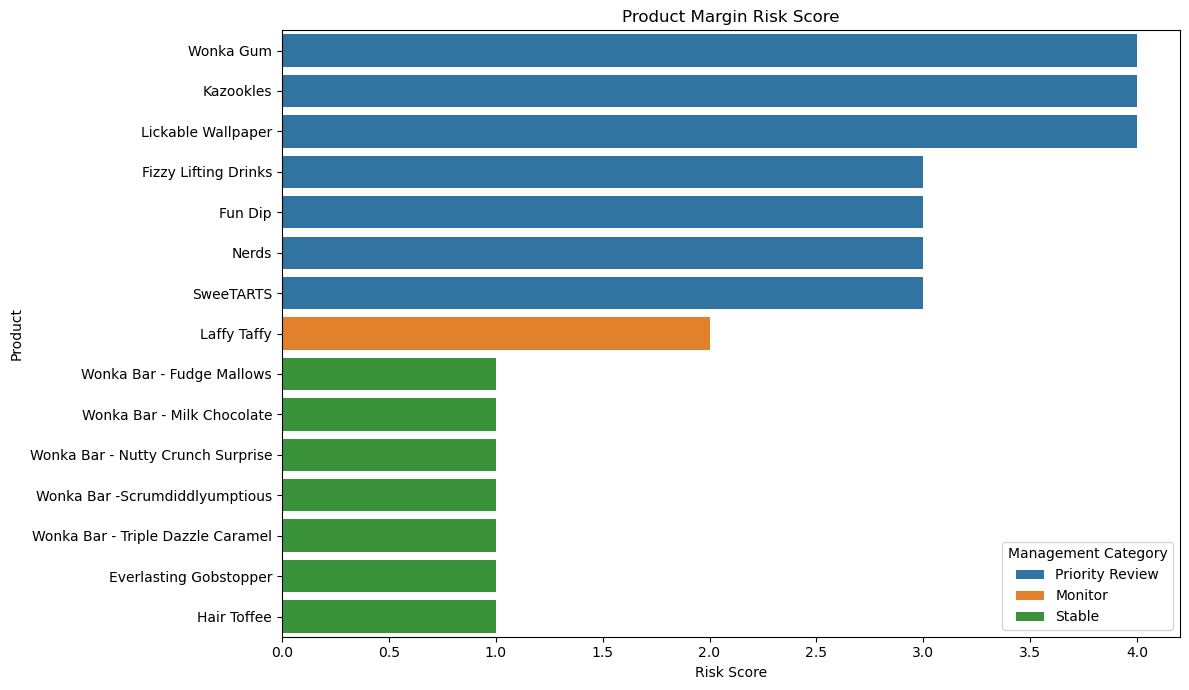

In [169]:
risk_sorted = product_analysis.sort_values(
    "Risk Score",
    ascending=False
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=risk_sorted,
    x="Risk Score",
    y="Product Name",
    hue="Management Category",
    dodge=False
)

plt.title("Product Margin Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

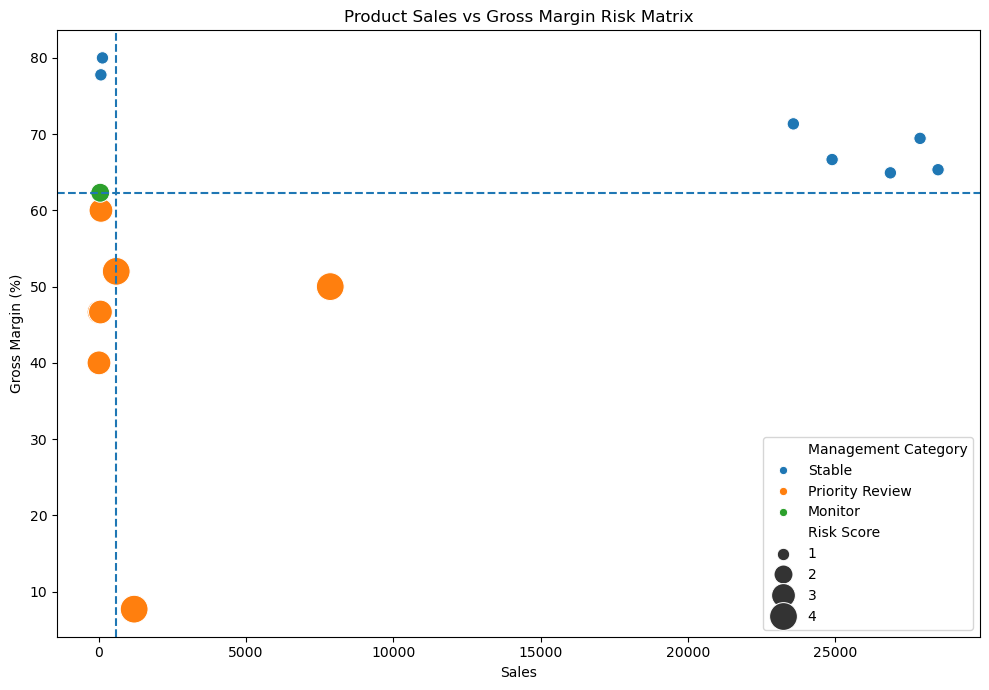

In [171]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=product_analysis,
    x="Sales",
    y="Gross Margin %",
    size="Risk Score",
    hue="Management Category",
    sizes=(80, 400)
)

plt.axvline(
    sales_median,
    linestyle="--"
)

plt.axhline(
    margin_median,
    linestyle="--"
)

plt.title("Product Sales vs Gross Margin Risk Matrix")
plt.xlabel("Sales")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [173]:
management_summary = (
    product_analysis["Management Category"]
    .value_counts()
    .reset_index()
)

management_summary.columns = [
    "Management Category",
    "Product Count"
]

management_summary

,Management Category,Product Count
0,Stable,7
1,Priority Review,7
2,Monitor,1


In [175]:
top_profit_product = product_analysis.loc[
    product_analysis["Gross Profit"].idxmax()
]

lowest_profit_product = product_analysis.loc[
    product_analysis["Gross Profit"].idxmin()
]

print("Top Profit Product:")
print(top_profit_product[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %"
    ]
])

print("\nLowest Profit Product:")
print(lowest_profit_product[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %"
    ]
])

Top Profit Product:
Product Name      Wonka Bar -Scrumdiddlyumptious
Division                               Chocolate
Sales                                    27874.8
Gross Profit                             19357.5
Gross Margin %                         69.444444
Name: 3, dtype: object

Lowest Profit Product:
Product Name      Fun Dip
Division            Sugar
Sales                12.0
Gross Profit          4.8
Gross Margin %       40.0
Name: 10, dtype: object


In [177]:
highest_margin_product = product_analysis.loc[
    product_analysis["Gross Margin %"].idxmax()
]

lowest_margin_product = product_analysis.loc[
    product_analysis["Gross Margin %"].idxmin()
]

print("Highest Margin Product:")
print(highest_margin_product[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %"
    ]
])

print("\nLowest Margin Product:")
print(lowest_margin_product[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %"
    ]
])

Highest Margin Product:
Product Name      Everlasting Gobstopper
Division                           Sugar
Sales                              130.0
Gross Profit                       104.0
Gross Margin %                      80.0
Name: 9, dtype: object

Lowest Margin Product:
Product Name      Kazookles
Division              Other
Sales               1205.75
Gross Profit          92.75
Gross Margin %     7.692308
Name: 7, dtype: object


In [179]:
strongest_division = division_performance.loc[
    division_performance["Gross Margin %"].idxmax()
]

weakest_division = division_performance.loc[
    division_performance["Gross Margin %"].idxmin()
]

print("Strongest Division by Margin:")
print(strongest_division[
    [
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
])

print("\nWeakest Division by Margin:")
print(weakest_division[
    [
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
])

Strongest Division by Margin:
Division           Chocolate
Sales               131692.9
Gross Profit        88824.62
Gross Margin %     67.448298
Profit per Unit     2.382954
Name: 0, dtype: object

Weakest Division by Margin:
Division               Other
Sales                9663.25
Gross Profit         4333.45
Gross Margin %     44.844643
Profit per Unit      3.48909
Name: 1, dtype: object


In [181]:
highest_revenue_product = product_analysis.loc[
    product_analysis["Sales"].idxmax()
]

print("Highest Revenue Product:")
print(highest_revenue_product[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %"
    ]
])

print("\nHighest Profit Product:")
print(top_profit_product[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %"
    ]
])

Highest Revenue Product:
Product Name      Wonka Bar - Triple Dazzle Caramel
Division                                  Chocolate
Sales                                       28485.0
Gross Profit                                18610.2
Gross Margin %                            65.333333
Name: 4, dtype: object

Highest Profit Product:
Product Name      Wonka Bar -Scrumdiddlyumptious
Division                               Chocolate
Sales                                    27874.8
Gross Profit                             19357.5
Gross Margin %                         69.444444
Name: 3, dtype: object


In [183]:
recommendation_table = product_analysis[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Cost %",
        "Margin Volatility",
        "Risk Score",
        "Management Category"
    ]
].copy()

def generate_recommendation(row):
    if row["Management Category"] == "Priority Review":
        return "Review pricing and cost structure"
    
    elif row["Management Category"] == "Monitor":
        return "Monitor margin and cost performance"
    
    else:
        return "Maintain and monitor performance"

recommendation_table["Recommendation"] = (
    recommendation_table.apply(
        generate_recommendation,
        axis=1
    )
)

recommendation_table.sort_values(
    "Risk Score",
    ascending=False
)

,Product Name,Division,Sales,Gross Profit,Gross Margin %,Cost %,Margin Volatility,Risk Score,Management Category,Recommendation
6,Wonka Gum,Other,597.50,310.70,52.000000,48.000000,2.095276e-15,4,Priority Review,Review pricing and cost structure
7,Kazookles,Other,1205.75,92.75,7.692308,92.307692,0.000000e+00,4,Priority Review,Review pricing and cost structure
8,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,50.000000,0.000000e+00,4,Priority Review,Review pricing and cost structure
5,Fizzy Lifting Drinks,Sugar,78.75,47.25,60.000000,40.000000,0.000000e+00,3,Priority Review,Review pricing and cost structure
10,Fun Dip,Sugar,12.00,4.80,40.000000,60.000000,0.000000e+00,3,Priority Review,Review pricing and cost structure
13,Nerds,Sugar,15.00,7.00,46.666667,53.333333,0.000000e+00,3,Priority Review,Review pricing and cost structure
14,SweeTARTS,Sugar,61.50,28.70,46.666667,53.333333,0.000000e+00,3,Priority Review,Review pricing and cost structure
12,Laffy Taffy,Sugar,53.73,33.48,62.311558,37.688442,0.000000e+00,2,Monitor,Monitor margin and cost performance
0,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.666667,33.333333,1.108716e-14,1,Stable,Maintain and monitor performance
1,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.923077,35.076923,9.827717e-15,1,Stable,Maintain and monitor performance


In [185]:
pricing_review = product_analysis[
    (
        product_analysis["Sales"] >= sales_median
    )
    &
    (
        product_analysis["Gross Margin %"] < margin_median
    )
].sort_values(
    "Sales",
    ascending=False
)

pricing_review[
    [
        "Product Name",
        "Division",
        "Sales",
        "Gross Profit",
        "Gross Margin %",
        "Cost %"
    ]
]

,Product Name,Division,Sales,Gross Profit,Gross Margin %,Cost %
8,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,50.000000
7,Kazookles,Other,1205.75,92.75,7.692308,92.307692
6,Wonka Gum,Other,597.50,310.70,52.000000,48.000000


In [187]:
cost_review = product_analysis[
    (
        product_analysis["Cost %"] >= cost_median
    )
    &
    (
        product_analysis["Gross Margin %"] < margin_median
    )
].sort_values(
    "Cost %",
    ascending=False
)

cost_review[
    [
        "Product Name",
        "Division",
        "Sales",
        "Cost %",
        "Gross Margin %",
        "Gross Profit"
    ]
]

,Product Name,Division,Sales,Cost %,Gross Margin %,Gross Profit
7,Kazookles,Other,1205.75,92.307692,7.692308,92.75
10,Fun Dip,Sugar,12.00,60.000000,40.000000,4.80
13,Nerds,Sugar,15.00,53.333333,46.666667,7.00
14,SweeTARTS,Sugar,61.50,53.333333,46.666667,28.70
8,Lickable Wallpaper,Other,7860.00,50.000000,50.000000,3930.00
6,Wonka Gum,Other,597.50,48.000000,52.000000,310.70
5,Fizzy Lifting Drinks,Sugar,78.75,40.000000,60.000000,47.25


In [189]:
recommendation_summary = pd.DataFrame({
    "Area": [
        "Pricing Review",
        "Cost Structure Review",
        "Margin Monitoring",
        "Stable Products"
    ],
    "Product Count": [
        len(pricing_review),
        len(cost_review),
        len(
            product_analysis[
                product_analysis["Management Category"] == "Monitor"
            ]
        ),
        len(
            product_analysis[
                product_analysis["Management Category"] == "Stable"
            ]
        )
    ]
})

recommendation_summary

,Area,Product Count
0,Pricing Review,3
1,Cost Structure Review,7
2,Margin Monitoring,1
3,Stable Products,7


In [191]:
df.to_csv(
    "Nassau_Candy_Analyzed.csv",
    index=False
)

print("Nassau_Candy_Analyzed.csv saved successfully.")

Nassau_Candy_Analyzed.csv saved successfully.


In [193]:
product_analysis.to_csv(
    "Product_Profitability_Analysis.csv",
    index=False
)

print("Product_Profitability_Analysis.csv saved successfully.")

Product_Profitability_Analysis.csv saved successfully.


In [195]:
division_performance.to_csv(
    "Division_Performance.csv",
    index=False
)

regional_performance.to_csv(
    "Regional_Performance.csv",
    index=False
)

print("Division and Regional analysis files saved successfully.")

Division and Regional analysis files saved successfully.


In [197]:
recommendation_table.to_csv(
    "Product_Recommendations.csv",
    index=False
)

concentration_summary.to_csv(
    "Profit_Concentration_Summary.csv",
    index=False
)

print("Recommendation and concentration files saved successfully.")

Recommendation and concentration files saved successfully.


In [199]:
print("Missing values in final dataset:")
print(df.isnull().sum().sum())

print("\nMissing values in product analysis:")
print(product_analysis.isnull().sum().sum())

Missing values in final dataset:
0

Missing values in product analysis:
0


In [201]:
print("Duplicate transaction rows:", df.duplicated().sum())

print(
    "Duplicate products:",
    product_analysis["Product ID"].duplicated().sum()
)

Duplicate transaction rows: 0
Duplicate products: 0


In [203]:
profit_validation = np.isclose(
    df["Gross Profit"],
    df["Sales"] - df["Cost"]
)

margin_validation = np.isclose(
    df["Gross Margin %"],
    (df["Gross Profit"] / df["Sales"]) * 100
)

print(
    "Incorrect Gross Profit calculations:",
    (~profit_validation).sum()
)

print(
    "Incorrect Gross Margin calculations:",
    (~margin_validation).sum()
)

Incorrect Gross Profit calculations: 0
Incorrect Gross Margin calculations: 0


In [205]:
print("Transaction records:", len(df))
print("Products analyzed:", len(product_analysis))
print("Divisions analyzed:", len(division_performance))
print("Regions analyzed:", len(regional_performance))

print("\nAnalysis validation completed.")

Transaction records: 10194
Products analyzed: 15
Divisions analyzed: 3
Regions analyzed: 4

Analysis validation completed.
